In [1]:
!pip install librosa soundfile seaborn gradio --quiet

import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


ERROR: Could not find a version that satisfies the requirement pydantic<2.12,>=2.0 (from gradio) (from versions: none)
ERROR: No matching distribution found for pydantic<2.12,>=2.0


device(type='cpu')

In [2]:
# Kaggle dataset folder (adjust if your dataset name differs)
DATA_DIR = Path("/kaggle/input/ravdess-emotional-speech-audio")

print("Data dir exists:", DATA_DIR.exists())

wav_files = list(DATA_DIR.rglob("*.wav"))
print("Number of audio files found:", len(wav_files))
wav_files[:5]


Data dir exists: True
Number of audio files found: 2880


[PosixPath('/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav'),
 PosixPath('/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav'),
 PosixPath('/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav'),
 PosixPath('/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav'),
 PosixPath('/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav')]

In [3]:
# Emotion ID → label
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

# Intensity ID → label
INTENSITY_MAP = {
    "01": "normal",
    "02": "strong",
}

# Reverse maps for codes
EMOTION_ID_MAP = {v: k for k, v in EMOTION_MAP.items()}       # "happy" -> "03"
INTENSITY_ID_MAP = {"normal": "01", "strong": "02"}           # "normal" -> "01"


def parse_labels_from_filename(path: Path):
    """
    Example: '03-01-05-02-02-01-12.wav'
    parts[2] = emotion id (EE)
    parts[3] = intensity id (II)
    """
    name = path.stem
    parts = name.split("-")
    emotion_id = parts[2]
    intensity_id = parts[3]
    emotion = EMOTION_MAP.get(emotion_id, "unknown")
    intensity = INTENSITY_MAP.get(intensity_id, "normal")
    return emotion, intensity, emotion_id, intensity_id


rows = []
for p in wav_files:
    emotion, intensity, emotion_id, intensity_id = parse_labels_from_filename(p)
    rows.append({
        "path": str(p),
        "emotion": emotion,
        "intensity": intensity,
        "emotion_id": emotion_id,
        "intensity_id": intensity_id,
    })

df = pd.DataFrame(rows)
print(df.head())

print("\nEmotion counts:")
print(df["emotion"].value_counts())

print("\nIntensity counts:")
print(df["intensity"].value_counts())


                                                path    emotion intensity  \
0  /kaggle/input/ravdess-emotional-speech-audio/A...  surprised    normal   
1  /kaggle/input/ravdess-emotional-speech-audio/A...    neutral    normal   
2  /kaggle/input/ravdess-emotional-speech-audio/A...    disgust    strong   
3  /kaggle/input/ravdess-emotional-speech-audio/A...    disgust    normal   
4  /kaggle/input/ravdess-emotional-speech-audio/A...    neutral    normal   

  emotion_id intensity_id  
0         08           01  
1         01           01  
2         07           02  
3         07           01  
4         01           01  

Emotion counts:
emotion
surprised    384
disgust      384
fearful      384
sad          384
calm         384
happy        384
angry        384
neutral      192
Name: count, dtype: int64

Intensity counts:
intensity
normal    1536
strong    1344
Name: count, dtype: int64


In [4]:
# Encode emotion labels 0..7
emotion_to_idx = {label: idx for idx, label in enumerate(sorted(df["emotion"].unique()))}
idx_to_emotion = {idx: label for label, idx in emotion_to_idx.items()}

# Encode intensity: normal=0, strong=1
intensity_to_idx = {"normal": 0, "strong": 1}
idx_to_intensity = {v: k for k, v in intensity_to_idx.items()}

df["emotion_label"] = df["emotion"].map(emotion_to_idx)
df["intensity_label"] = df["intensity"].map(intensity_to_idx)

# For stratify we use emotion
df["label"] = df["emotion_label"]

train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"]
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

train_df.head()


Train size: 2016
Val size: 432
Test size: 432


,path,emotion,intensity,emotion_id,intensity_id,emotion_label,intensity_label,label
1763,/kaggle/input/ravdess-emotional-speech-audio/a...,disgust,strong,07,02,2,1,2
1821,/kaggle/input/ravdess-emotional-speech-audio/a...,fearful,normal,06,01,3,0,3
1992,/kaggle/input/ravdess-emotional-speech-audio/a...,surprised,strong,08,02,7,1,7
2055,/kaggle/input/ravdess-emotional-speech-audio/a...,calm,normal,02,01,1,0,1
818,/kaggle/input/ravdess-emotional-speech-audio/A...,calm,strong,02,02,1,1,1


In [5]:
def load_mel_spectrogram(
    path,
    sr=16000,
    n_mels=64,
    n_fft=1024,
    hop_length=512,
    max_len=128
):
    y, sr = librosa.load(path, sr=sr, mono=True)
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
    )
    mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    # pad / truncate time
    if mel_spec.shape[1] < max_len:
        pad_width = max_len - mel_spec.shape[1]
        mel_spec = np.pad(mel_spec, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_spec = mel_spec[:, :max_len]

    return mel_spec  # (n_mels, max_len)


def load_mfcc_sequence(
    path,
    sr=16000,
    n_mfcc=40,
    n_fft=1024,
    hop_length=512,
    max_len=200
):
    y, sr = librosa.load(path, sr=sr, mono=True)
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length,
    )  # (n_mfcc, time)

    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mfcc = mfcc[:, :max_len]

    mfcc = mfcc.T  # (time, n_mfcc)
    return mfcc


# quick sanity checks
print("Mel shape:", load_mel_spectrogram(train_df.iloc[0]["path"]).shape)
print("MFCC shape:", load_mfcc_sequence(train_df.iloc[0]["path"]).shape)


Mel shape: (64, 128)
MFCC shape: (200, 40)


In [6]:
class RavdessMelDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        e = row["emotion_label"]
        i = row["intensity_label"]

        mel = load_mel_spectrogram(path)  # (64, 128)
        mel = mel[np.newaxis, :, :]       # (1, 64, 128)

        x = torch.tensor(mel, dtype=torch.float32)
        y_e = torch.tensor(e, dtype=torch.long)
        y_i = torch.tensor(i, dtype=torch.long)
        return x, y_e, y_i


batch_size = 32

train_mel_dataset = RavdessMelDataset(train_df)
val_mel_dataset   = RavdessMelDataset(val_df)
test_mel_dataset  = RavdessMelDataset(test_df)

train_mel_loader = DataLoader(train_mel_dataset, batch_size=batch_size, shuffle=True)
val_mel_loader   = DataLoader(val_mel_dataset, batch_size=batch_size, shuffle=False)
test_mel_loader  = DataLoader(test_mel_dataset, batch_size=batch_size, shuffle=False)

x_batch, y_e_batch, y_i_batch = next(iter(train_mel_loader))
print("Mel batch:", x_batch.shape, y_e_batch.shape, y_i_batch.shape)


Mel batch: torch.Size([32, 1, 64, 128]) torch.Size([32]) torch.Size([32])


In [7]:
num_emotions = len(emotion_to_idx)
num_intensities = len(intensity_to_idx)

class CNNEmotionNet(nn.Module):
    def __init__(self, num_emotions, num_intensities):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc_emotion = nn.Linear(128, num_emotions)
        self.fc_intensity = nn.Linear(128, num_intensities)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        out_e = self.fc_emotion(x)
        out_i = self.fc_intensity(x)
        return out_e, out_i


model_cnn = CNNEmotionNet(num_emotions, num_intensities).to(device)
model_cnn


CNNEmotionNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc_emotion): Linear(in_features=128, out_features=8, bias=True)
  (fc_intensity): Linear(in_features=128, out_features=2, bias=True)
)

In [8]:
import torch.optim as optim
from tqdm.auto import tqdm

criterion_emotion = nn.CrossEntropyLoss()
criterion_intensity = nn.CrossEntropyLoss()

def train_one_epoch_cnn(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_e_correct = 0
    total_i_correct = 0
    total = 0

    for x, y_e, y_i in tqdm(loader, leave=False):
        x, y_e, y_i = x.to(device), y_e.to(device), y_i.to(device)

        optimizer.zero_grad()
        logits_e, logits_i = model(x)
        loss_e = criterion_emotion(logits_e, y_e)
        loss_i = criterion_intensity(logits_i, y_i)
        loss = loss_e + loss_i
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds_e = logits_e.argmax(dim=1)
        preds_i = logits_i.argmax(dim=1)
        total_e_correct += (preds_e == y_e).sum().item()
        total_i_correct += (preds_i == y_i).sum().item()
        total += y_e.size(0)

    return (
        total_loss / total,
        total_e_correct / total,
        total_i_correct / total,
    )


def evaluate_cnn(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_e_correct = 0
    total_i_correct = 0
    total = 0

    with torch.no_grad():
        for x, y_e, y_i in loader:
            x, y_e, y_i = x.to(device), y_e.to(device), y_i.to(device)
            logits_e, logits_i = model(x)
            loss_e = criterion_emotion(logits_e, y_e)
            loss_i = criterion_intensity(logits_i, y_i)
            loss = loss_e + loss_i

            total_loss += loss.item() * x.size(0)
            preds_e = logits_e.argmax(dim=1)
            preds_i = logits_i.argmax(dim=1)
            total_e_correct += (preds_e == y_e).sum().item()
            total_i_correct += (preds_i == y_i).sum().item()
            total += y_e.size(0)

    return (
        total_loss / total,
        total_e_correct / total,
        total_i_correct / total,
    )


In [9]:
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=1e-3)

num_epochs_cnn = 10  # adjust if you want
history_cnn = {
    "train_loss": [],
    "train_e_acc": [],
    "train_i_acc": [],
    "val_loss": [],
    "val_e_acc": [],
    "val_i_acc": [],
}

for epoch in range(1, num_epochs_cnn + 1):
    train_loss, train_e_acc, train_i_acc = train_one_epoch_cnn(model_cnn, train_mel_loader, optimizer_cnn, device)
    val_loss, val_e_acc, val_i_acc = evaluate_cnn(model_cnn, val_mel_loader, device)

    history_cnn["train_loss"].append(train_loss)
    history_cnn["train_e_acc"].append(train_e_acc)
    history_cnn["train_i_acc"].append(train_i_acc)
    history_cnn["val_loss"].append(val_loss)
    history_cnn["val_e_acc"].append(val_e_acc)
    history_cnn["val_i_acc"].append(val_i_acc)

    print(
        f"[CNN] Epoch {epoch}/{num_epochs_cnn} "
        f"- train_loss: {train_loss:.4f}, train_e_acc: {train_e_acc:.4f}, train_i_acc: {train_i_acc:.4f}; "
        f"val_loss: {val_loss:.4f}, val_e_acc: {val_e_acc:.4f}, val_i_acc: {val_i_acc:.4f}"
    )


  0%|          | 0/63 [00:00<?, ?it/s]

[CNN] Epoch 1/10 - train_loss: 2.8175, train_e_acc: 0.1389, train_i_acc: 0.5521; val_loss: 2.7209, val_e_acc: 0.1898, val_i_acc: 0.6736


  0%|          | 0/63 [00:00<?, ?it/s]

[CNN] Epoch 2/10 - train_loss: 2.7023, train_e_acc: 0.1726, train_i_acc: 0.6181; val_loss: 2.6074, val_e_acc: 0.1898, val_i_acc: 0.6806


  0%|          | 0/63 [00:00<?, ?it/s]

...

[CNN] Epoch 8/10 - train_loss: 2.4208, train_e_acc: 0.2659, train_i_acc: 0.7192; val_loss: 2.3740, val_e_acc: 0.3079, val_i_acc: 0.7431


  0%|          | 0/63 [00:00<?, ?it/s]

[CNN] Epoch 9/10 - train_loss: 2.3811, train_e_acc: 0.2877, train_i_acc: 0.7029; val_loss: 2.2459, val_e_acc: 0.3681, val_i_acc: 0.7269


  0%|          | 0/63 [00:00<?, ?it/s]

[CNN] Epoch 10/10 - train_loss: 2.3204, train_e_acc: 0.3090, train_i_acc: 0.7197; val_loss: 2.2064, val_e_acc: 0.3889, val_i_acc: 0.7083


In [10]:
class RavdessMFCCDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        e = row["emotion_label"]
        i = row["intensity_label"]

        seq = load_mfcc_sequence(path)  # (T, 40)
        x = torch.tensor(seq, dtype=torch.float32)
        y_e = torch.tensor(e, dtype=torch.long)
        y_i = torch.tensor(i, dtype=torch.long)
        return x, y_e, y_i


def collate_fn_padded(batch):
    sequences, labels_e, labels_i = zip(*batch)
    lengths = torch.tensor([s.shape[0] for s in sequences], dtype=torch.long)
    padded = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)  # (B, T_max, F)
    labels_e = torch.tensor(labels_e, dtype=torch.long)
    labels_i = torch.tensor(labels_i, dtype=torch.long)
    return padded, labels_e, labels_i, lengths


train_mfcc_dataset = RavdessMFCCDataset(train_df)
val_mfcc_dataset   = RavdessMFCCDataset(val_df)
test_mfcc_dataset  = RavdessMFCCDataset(test_df)

train_mfcc_loader = DataLoader(train_mfcc_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_padded)
val_mfcc_loader   = DataLoader(val_mfcc_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_padded)
test_mfcc_loader  = DataLoader(test_mfcc_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_padded)

x_mfcc, y_e_mfcc, y_i_mfcc, lengths = next(iter(train_mfcc_loader))
print("MFCC batch:", x_mfcc.shape, y_e_mfcc.shape, y_i_mfcc.shape, lengths[:5])


MFCC batch: torch.Size([32, 200, 40]) torch.Size([32]) torch.Size([32]) tensor([200, 200, 200, 200, 200])


In [11]:
class LSTMEmotionNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_emotions, num_intensities, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
        )
        direction_factor = 2 if bidirectional else 1
        self.dropout = nn.Dropout(0.5)
        self.fc_emotion = nn.Linear(hidden_dim * direction_factor, num_emotions)
        self.fc_intensity = nn.Linear(hidden_dim * direction_factor, num_intensities)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, (h_n, c_n) = self.lstm(packed)

        if self.bidirectional:
            h_forward = h_n[-2]
            h_backward = h_n[-1]
            h = torch.cat((h_forward, h_backward), dim=1)
        else:
            h = h_n[-1]

        h = self.dropout(h)
        out_e = self.fc_emotion(h)
        out_i = self.fc_intensity(h)
        return out_e, out_i


input_dim = 40
hidden_dim = 128
num_layers = 2

model_lstm = LSTMEmotionNet(input_dim, hidden_dim, num_layers, num_emotions, num_intensities).to(device)
model_lstm


LSTMEmotionNet(
  (lstm): LSTM(40, 128, num_layers=2, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc_emotion): Linear(in_features=256, out_features=8, bias=True)
  (fc_intensity): Linear(in_features=256, out_features=2, bias=True)
)

In [12]:
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3)

def train_one_epoch_lstm(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_e_correct = 0
    total_i_correct = 0
    total = 0

    for x, y_e, y_i, lengths in tqdm(loader, leave=False):
        x, y_e, y_i, lengths = x.to(device), y_e.to(device), y_i.to(device), lengths.to(device)

        optimizer.zero_grad()
        logits_e, logits_i = model(x, lengths)
        loss_e = criterion_emotion(logits_e, y_e)
        loss_i = criterion_intensity(logits_i, y_i)
        loss = loss_e + loss_i
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds_e = logits_e.argmax(dim=1)
        preds_i = logits_i.argmax(dim=1)
        total_e_correct += (preds_e == y_e).sum().item()
        total_i_correct += (preds_i == y_i).sum().item()
        total += y_e.size(0)

    return total_loss / total, total_e_correct / total, total_i_correct / total


def evaluate_lstm(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_e_correct = 0
    total_i_correct = 0
    total = 0

    with torch.no_grad():
        for x, y_e, y_i, lengths in loader:
            x, y_e, y_i, lengths = x.to(device), y_e.to(device), y_i.to(device), lengths.to(device)
            logits_e, logits_i = model(x, lengths)
            loss_e = criterion_emotion(logits_e, y_e)
            loss_i = criterion_intensity(logits_i, y_i)
            loss = loss_e + loss_i

            total_loss += loss.item() * x.size(0)
            preds_e = logits_e.argmax(dim=1)
            preds_i = logits_i.argmax(dim=1)
            total_e_correct += (preds_e == y_e).sum().item()
            total_i_correct += (preds_i == y_i).sum().item()
            total += y_e.size(0)

    return total_loss / total, total_e_correct / total, total_i_correct / total


num_epochs_lstm = 10
history_lstm = {
    "train_loss": [],
    "train_e_acc": [],
    "train_i_acc": [],
    "val_loss": [],
    "val_e_acc": [],
    "val_i_acc": [],
}

for epoch in range(1, num_epochs_lstm + 1):
    train_loss, train_e_acc, train_i_acc = train_one_epoch_lstm(model_lstm, train_mfcc_loader, optimizer_lstm, device)
    val_loss, val_e_acc, val_i_acc = evaluate_lstm(model_lstm, val_mfcc_loader, device)

    history_lstm["train_loss"].append(train_loss)
    history_lstm["train_e_acc"].append(train_e_acc)
    history_lstm["train_i_acc"].append(train_i_acc)
    history_lstm["val_loss"].append(val_loss)
    history_lstm["val_e_acc"].append(val_e_acc)
    history_lstm["val_i_acc"].append(val_i_acc)

    print(
        f"[LSTM] Epoch {epoch}/{num_epochs_lstm} "
        f"- train_loss: {train_loss:.4f}, train_e_acc: {train_e_acc:.4f}, train_i_acc: {train_i_acc:.4f}; "
        f"val_loss: {val_loss:.4f}, val_e_acc: {val_e_acc:.4f}, val_i_acc: {val_i_acc:.4f}"
    )


  0%|          | 0/63 [00:00<?, ?it/s]

[LSTM] Epoch 1/10 - train_loss: 2.6297, train_e_acc: 0.1930, train_i_acc: 0.6364; val_loss: 2.3980, val_e_acc: 0.2708, val_i_acc: 0.7106


  0%|          | 0/63 [00:00<?, ?it/s]

[LSTM] Epoch 2/10 - train_loss: 2.3936, train_e_acc: 0.2599, train_i_acc: 0.7302; val_loss: 2.2578, val_e_acc: 0.3148, val_i_acc: 0.7106


  0%|          | 0/63 [00:00<?, ?it/s]

...

[LSTM] Epoch 8/10 - train_loss: 2.0127, train_e_acc: 0.3914, train_i_acc: 0.7644; val_loss: 2.0484, val_e_acc: 0.3657, val_i_acc: 0.7639


  0%|          | 0/63 [00:00<?, ?it/s]

[LSTM] Epoch 9/10 - train_loss: 1.9751, train_e_acc: 0.4053, train_i_acc: 0.7708; val_loss: 1.8803, val_e_acc: 0.4398, val_i_acc: 0.7940


  0%|          | 0/63 [00:00<?, ?it/s]

[LSTM] Epoch 10/10 - train_loss: 1.8941, train_e_acc: 0.4400, train_i_acc: 0.7812; val_loss: 2.0222, val_e_acc: 0.3773, val_i_acc: 0.7569


In [13]:
os.makedirs("saved_models", exist_ok=True)

torch.save(model_cnn.state_dict(), "saved_models/cnn_ravdess.pth")
torch.save(model_lstm.state_dict(), "saved_models/lstm_ravdess.pth")

print("✅ Saved CNN and LSTM models.")


✅ Saved CNN and LSTM models.


Models reloaded successfully.
Running CNN predictions...
Running LSTM predictions...

=== CNN Emotion Confusion Matrix ===


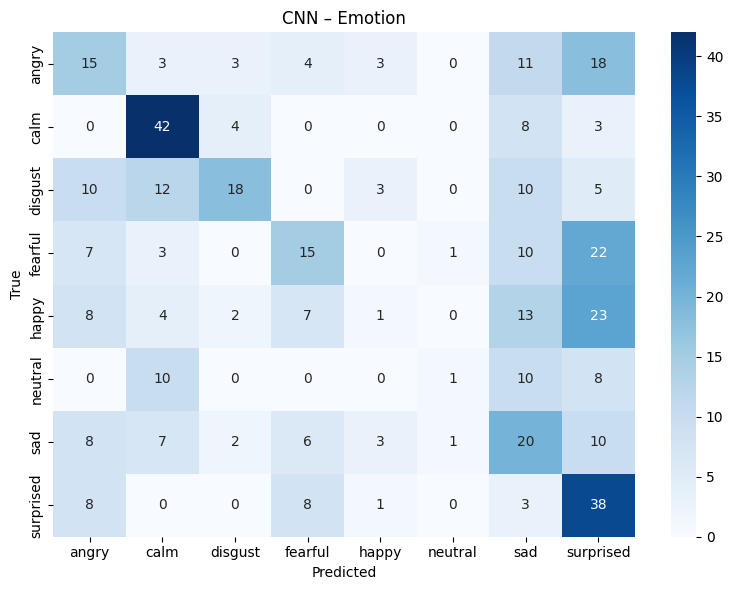

CNN Emotion IoU: {'angry': 0.15306122448979592, 'calm': 0.4375, 'disgust': 0.2608695652173913, 'fearful': 0.18072289156626506, 'happy': 0.014705882352941176, 'neutral': 0.03225806451612903, 'sad': 0.16393442622950818, 'surprised': 0.2585034013605442}
CNN Mean IoU (Emotion): 0.18769443196657187

=== LSTM Emotion Confusion Matrix ===


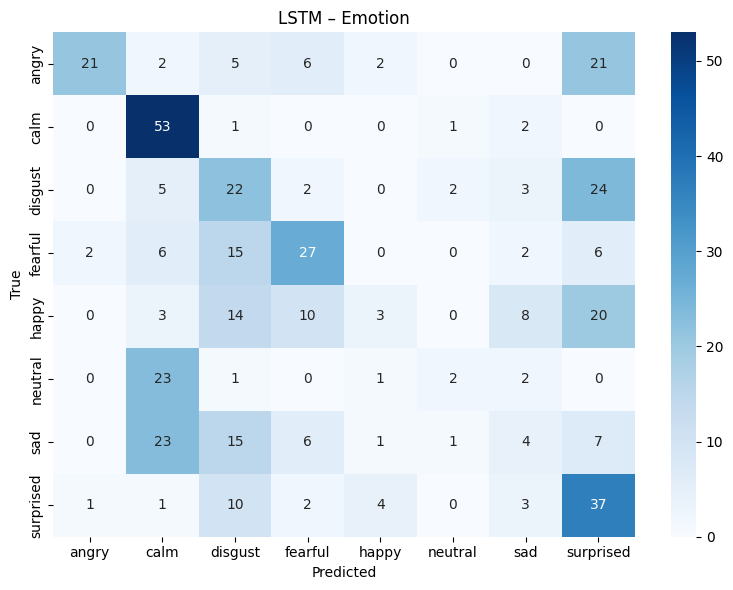

LSTM Emotion IoU: {'angry': 0.35, 'calm': 0.44166666666666665, 'disgust': 0.18487394957983194, 'fearful': 0.32142857142857145, 'happy': 0.045454545454545456, 'neutral': 0.06060606060606061, 'sad': 0.05194805194805195, 'surprised': 0.27205882352941174}
LSTM Mean IoU (Emotion): 0.21600458365164246

=== CNN Intensity Confusion Matrix ===


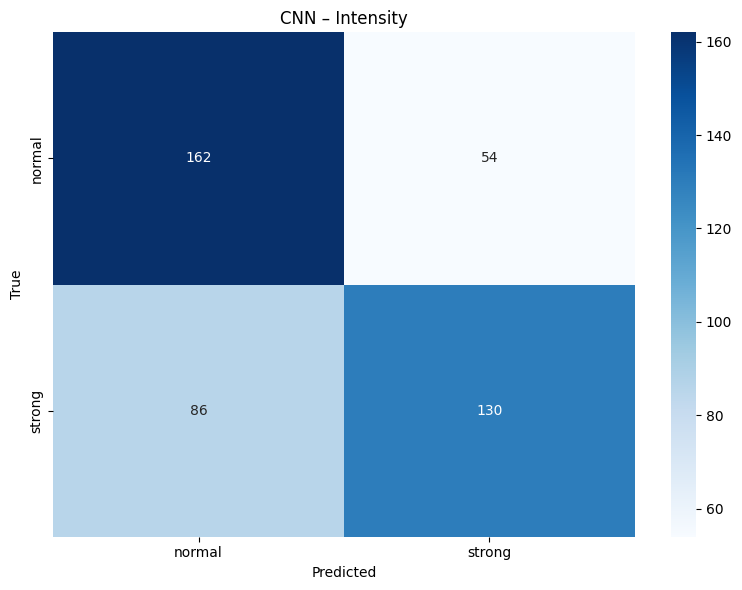

CNN Intensity IoU: {'normal': 0.5364238410596026, 'strong': 0.48148148148148145}
CNN Mean IoU (Intensity): 0.5089526612705421

=== LSTM Intensity Confusion Matrix ===


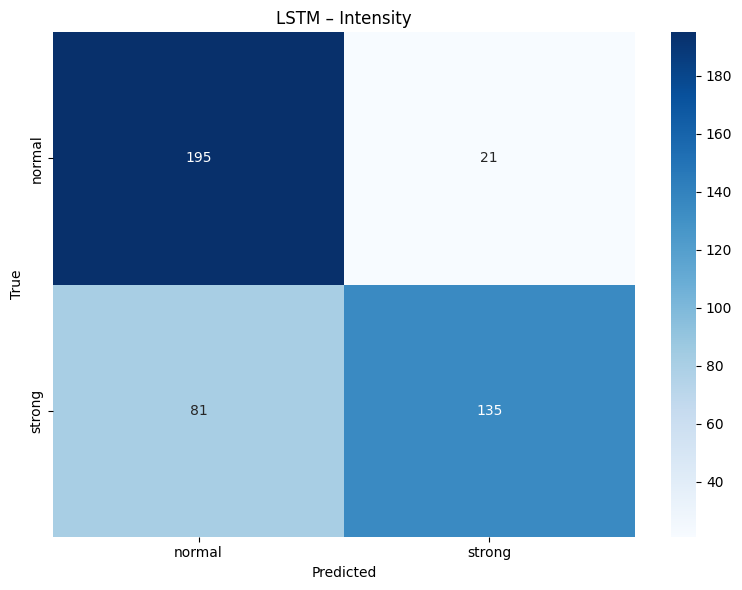

LSTM Intensity IoU: {'normal': 0.6565656565656566, 'strong': 0.569620253164557}
LSTM Mean IoU (Intensity): 0.6130929548651067


,Model,Task,Accuracy,Mean IoU
0,CNN,Emotion,0.347,0.188
1,CNN,Intensity,0.676,0.509
2,LSTM,Emotion,0.391,0.216
3,LSTM,Intensity,0.764,0.613



Raw Table:

Model      Task  Accuracy  Mean IoU
  CNN   Emotion  0.347222  0.187694
  CNN Intensity  0.675926  0.508953
 LSTM   Emotion  0.391204  0.216005
 LSTM Intensity  0.763889  0.613093


=== Example Predictions ===

File: 03-01-07-01-02-01-06.wav
True:        disgust / normal
CNN pred:    02 calm / 01 normal
LSTM pred:   02 calm / 01 normal
------------------------------------------------------------

File: 03-01-04-01-01-02-02.wav
True:        sad / normal
CNN pred:    04 sad / 01 normal
LSTM pred:   02 calm / 01 normal
------------------------------------------------------------

File: 03-01-03-01-02-01-12.wav
True:        happy / normal
CNN pred:    08 surprised / 01 normal
LSTM pred:   07 disgust / 01 normal
------------------------------------------------------------

File: 03-01-07-02-02-02-18.wav
True:        disgust / strong
CNN pred:    05 angry / 02 strong
LSTM pred:   06 fearful / 02 strong
------------------------------------------------------------

File: 03-01-07-

In [14]:
# ================================
#   FIXED RESULTS + ANALYSIS
#   Works even after restart
# ================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --------------------------------------------------------
# 1) Reload models safely (in case of kernel restart)
# --------------------------------------------------------

# Recreate model architectures
model_cnn = CNNEmotionNet(num_emotions, num_intensities).to(device)
model_lstm = LSTMEmotionNet(input_dim, hidden_dim, num_layers, num_emotions, num_intensities).to(device)

# Load weights
model_cnn.load_state_dict(torch.load("saved_models/cnn_ravdess.pth", map_location=device))
model_lstm.load_state_dict(torch.load("saved_models/lstm_ravdess.pth", map_location=device))

model_cnn.eval()
model_lstm.eval()

print("Models reloaded successfully.")


# --------------------------------------------------------
# 2) Predictors (emotion & intensity)
# --------------------------------------------------------

def get_predictions_cnn(model, loader, device):
    model.eval()
    y_e_true, y_e_pred = [], []
    y_i_true, y_i_pred = [], []

    with torch.no_grad():
        for x, y_e, y_i in loader:
            x, y_e, y_i = x.to(device), y_e.to(device), y_i.to(device)
            logits_e, logits_i = model(x)

            y_e_pred.extend(torch.argmax(logits_e, dim=1).cpu().numpy())
            y_i_pred.extend(torch.argmax(logits_i, dim=1).cpu().numpy())

            y_e_true.extend(y_e.cpu().numpy())
            y_i_true.extend(y_i.cpu().numpy())

    return np.array(y_e_true), np.array(y_e_pred), np.array(y_i_true), np.array(y_i_pred)


def get_predictions_lstm(model, loader, device):
    model.eval()
    y_e_true, y_e_pred = [], []
    y_i_true, y_i_pred = [], []

    with torch.no_grad():
        for x, y_e, y_i, lengths in loader:
            x, y_e, y_i, lengths = x.to(device), y_e.to(device), y_i.to(device), lengths.to(device)
            logits_e, logits_i = model(x, lengths)

            y_e_pred.extend(torch.argmax(logits_e, dim=1).cpu().numpy())
            y_i_pred.extend(torch.argmax(logits_i, dim=1).cpu().numpy())

            y_e_true.extend(y_e.cpu().numpy())
            y_i_true.extend(y_i.cpu().numpy())

    return np.array(y_e_true), np.array(y_e_pred), np.array(y_i_true), np.array(y_i_pred)


# --------------------------------------------------------
# 3) Run predictions on test set
# --------------------------------------------------------

print("Running CNN predictions...")
y_e_true_cnn, y_e_pred_cnn, y_i_true_cnn, y_i_pred_cnn = get_predictions_cnn(model_cnn, test_mel_loader, device)

print("Running LSTM predictions...")
y_e_true_lstm, y_e_pred_lstm, y_i_true_lstm, y_i_pred_lstm = get_predictions_lstm(model_lstm, test_mfcc_loader, device)


# --------------------------------------------------------
# 4) Confusion matrix plotting
# --------------------------------------------------------

def plot_conf_mat(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return cm


# --------------------------------------------------------
# 5) IoU computation
# --------------------------------------------------------

def compute_iou_from_cm(cm, class_names):
    ious = {}
    for i, name in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        denom = tp + fp + fn
        iou = tp / denom if denom > 0 else 0.0
        ious[name] = iou

    mean_iou = np.mean(list(ious.values()))
    return ious, mean_iou


emotion_labels = [idx_to_emotion[i] for i in range(num_emotions)]
intensity_labels = [idx_to_intensity[i] for i in range(num_intensities)]


# --------------------------------------------------------
# 6) Emotion confusion matrices + IoU
# --------------------------------------------------------

print("\n=== CNN Emotion Confusion Matrix ===")
cm_e_cnn = plot_conf_mat(y_e_true_cnn, y_e_pred_cnn, emotion_labels, "CNN – Emotion")

ious_e_cnn, mean_iou_e_cnn = compute_iou_from_cm(cm_e_cnn, emotion_labels)
print("CNN Emotion IoU:", ious_e_cnn)
print("CNN Mean IoU (Emotion):", mean_iou_e_cnn)


print("\n=== LSTM Emotion Confusion Matrix ===")
cm_e_lstm = plot_conf_mat(y_e_true_lstm, y_e_pred_lstm, emotion_labels, "LSTM – Emotion")

ious_e_lstm, mean_iou_e_lstm = compute_iou_from_cm(cm_e_lstm, emotion_labels)
print("LSTM Emotion IoU:", ious_e_lstm)
print("LSTM Mean IoU (Emotion):", mean_iou_e_lstm)


# --------------------------------------------------------
# 7) Intensity confusion matrices + IoU
# --------------------------------------------------------

print("\n=== CNN Intensity Confusion Matrix ===")
cm_i_cnn = plot_conf_mat(y_i_true_cnn, y_i_pred_cnn, intensity_labels, "CNN – Intensity")

ious_i_cnn, mean_iou_i_cnn = compute_iou_from_cm(cm_i_cnn, intensity_labels)
print("CNN Intensity IoU:", ious_i_cnn)
print("CNN Mean IoU (Intensity):", mean_iou_i_cnn)


print("\n=== LSTM Intensity Confusion Matrix ===")
cm_i_lstm = plot_conf_mat(y_i_true_lstm, y_i_pred_lstm, intensity_labels, "LSTM – Intensity")

ious_i_lstm, mean_iou_i_lstm = compute_iou_from_cm(cm_i_lstm, intensity_labels)
print("LSTM Intensity IoU:", ious_i_lstm)
print("LSTM Mean IoU (Intensity):", mean_iou_i_lstm)


# --------------------------------------------------------
# 8) Accuracy calculations
# --------------------------------------------------------

acc_e_cnn  = accuracy_score(y_e_true_cnn, y_e_pred_cnn)
acc_e_lstm = accuracy_score(y_e_true_lstm, y_e_pred_lstm)

acc_i_cnn  = accuracy_score(y_i_true_cnn, y_i_pred_cnn)
acc_i_lstm = accuracy_score(y_i_true_lstm, y_i_pred_lstm)


# --------------------------------------------------------
# 9) Build Results Table
# --------------------------------------------------------

results = pd.DataFrame([
    ["CNN",  "Emotion",   acc_e_cnn,  mean_iou_e_cnn],
    ["CNN",  "Intensity", acc_i_cnn,  mean_iou_i_cnn],
    ["LSTM", "Emotion",   acc_e_lstm, mean_iou_e_lstm],
    ["LSTM", "Intensity", acc_i_lstm, mean_iou_i_lstm],
], columns=["Model", "Task", "Accuracy", "Mean IoU"])

display(results.style.format({"Accuracy": "{:.3f}", "Mean IoU": "{:.3f}"}).set_caption("Performance Summary"))

print("\nRaw Table:\n")
print(results.to_string(index=False))


# --------------------------------------------------------
# 10) Exemplary Outputs from Test Set
# --------------------------------------------------------

def predict_single(path, model_choice="CNN"):
    if model_choice == "CNN":
        mel = load_mel_spectrogram(path)
        mel = mel[np.newaxis, np.newaxis, :, :]
        x = torch.tensor(mel, dtype=torch.float32).to(device)
        with torch.no_grad():
            logits_e, logits_i = model_cnn(x)
    else:
        mfcc = load_mfcc_sequence(path)
        mfcc = mfcc[np.newaxis, :, :]
        x = torch.tensor(mfcc, dtype=torch.float32).to(device)
        lengths = torch.tensor([mfcc.shape[1]], dtype=torch.long).to(device)
        with torch.no_grad():
            logits_e, logits_i = model_lstm(x, lengths)

    probs_e = torch.softmax(logits_e, dim=1).cpu().numpy()[0]
    probs_i = torch.softmax(logits_i, dim=1).cpu().numpy()[0]

    e_idx = np.argmax(probs_e)
    i_idx = np.argmax(probs_i)

    e_label = idx_to_emotion[e_idx]
    i_label = idx_to_intensity[i_idx]

    e_code = EMOTION_ID_MAP[e_label]
    i_code = INTENSITY_ID_MAP[i_label]

    return e_label, e_code, i_label, i_code


print("\n\n=== Example Predictions ===")
for i in range(5):
    row = test_df.sample(1).iloc[0]
    path = row["path"]

    true_e = row["emotion"]
    true_i = row["intensity"]

    cnn_e, cnn_e_code, cnn_i, cnn_i_code = predict_single(path, "CNN")
    lstm_e, lstm_e_code, lstm_i, lstm_i_code = predict_single(path, "LSTM")

    print("\nFile:", os.path.basename(path))
    print("True:       ", true_e, "/", true_i)
    print("CNN pred:   ", cnn_e_code, cnn_e, "/", cnn_i_code, cnn_i)
    print("LSTM pred:  ", lstm_e_code, lstm_e, "/", lstm_i_code, lstm_i)
    print("-" * 60)
